# CNN Molecule Classification Example

This notebook reads only manual_labels.csv and the crops folder for the selected dataset. Training labels come from the human_class column; clustering labels, original .p files, and reference annotations are not used.

The configuration cell can switch between Ag111_APT_CO_044__p and Helicene_Ag(111)020__sxm.

Run the cells from top to bottom. After changing ACTIVE_IMAGE, rerun from the path-configuration cell onward.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'
print('PyTorch:', torch.__version__)
print('Device available:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.13.0
Device available: cpu


In [2]:
IMAGE_FOLDER_NAMES = (
    'Ag111_APT_CO_044__p',
    'Helicene_Ag(111)020__sxm',
)

def is_manual_label_root(data_directory):
    if not data_directory.is_dir():
        return False
    return any(
        (data_directory / name / 'manual_labels.csv').is_file()
        and (data_directory / name / 'crops').is_dir()
        for name in IMAGE_FOLDER_NAMES
    )


def locate_data_directory():
    candidates = [
        Path.cwd(),
        Path.cwd() / 'Data',
        Path.cwd() / 'project data' / 'Data',
        Path.cwd().parent / 'Data',
        Path.cwd().parent.parent / 'Data',
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if is_manual_label_root(candidate):
            return candidate.parent
        if candidate.is_dir() and any(
            is_manual_label_root(child)
            for child in candidate.iterdir()
            if child.is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        'Could not find the Data directory with manual-label folders. '
        'Start Jupyter from the project root or project data/Data.'
    )


DATA_DIRECTORY = locate_data_directory()
LABEL_ROOT = next(
    candidate for candidate in DATA_DIRECTORY.iterdir()
    if is_manual_label_root(candidate)
)

# Change only this line to switch the example dataset.
IMAGE_FOLDERS = {
    'Ag111_APT_CO_044__p': LABEL_ROOT / 'Ag111_APT_CO_044__p',
    'Helicene_Ag(111)020__sxm': LABEL_ROOT / 'Helicene_Ag(111)020__sxm',
}
# ACTIVE_IMAGE = 'Ag111_APT_CO_044__p'
ACTIVE_IMAGE = 'Helicene_Ag(111)020__sxm'



if ACTIVE_IMAGE not in IMAGE_FOLDERS:
    raise KeyError('Unknown dataset {}. Choose from {}'.format(ACTIVE_IMAGE, list(IMAGE_FOLDERS)))

LABEL_DIRECTORY = IMAGE_FOLDERS[ACTIVE_IMAGE]
LABEL_CSV = LABEL_DIRECTORY / 'manual_labels.csv'
CROP_DIRECTORY = LABEL_DIRECTORY / 'crops'
OUTPUT_DIRECTORY = DATA_DIRECTORY / 'cnn_results' / ACTIVE_IMAGE

print('Data directory:', DATA_DIRECTORY)
print('Active image:', ACTIVE_IMAGE)
print('Label CSV:', LABEL_CSV)
print('Crop directory:', CROP_DIRECTORY)
print('Output directory:', OUTPUT_DIRECTORY)

Data directory: /Users/jiajie/Desktop/ADS2002GroupCM1/Data
Active image: Helicene_Ag(111)020__sxm
Label CSV: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/Manual label/Helicene_Ag(111)020__sxm/manual_labels.csv
Crop directory: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/Manual label/Helicene_Ag(111)020__sxm/crops
Output directory: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm


In [3]:
# Load the manual labels. Training uses only crop_path and human_class.
if not LABEL_CSV.exists():
    raise FileNotFoundError('Manual-label CSV not found: {}'.format(LABEL_CSV))
if not CROP_DIRECTORY.is_dir():
    raise FileNotFoundError('Crop directory not found: {}'.format(CROP_DIRECTORY))

labels = pd.read_csv(LABEL_CSV, encoding='utf-8-sig')
required_columns = {'human_class', 'crop_path'}
missing_columns = required_columns.difference(labels.columns)
if missing_columns:
    raise ValueError('CSV is missing required columns: {}'.format(sorted(missing_columns)))

labels['human_class'] = labels['human_class'].fillna('').astype(str).str.strip()
labels['crop_path'] = labels['crop_path'].fillna('').astype(str).str.strip()
labels['_crop_path'] = labels['crop_path'].map(
    lambda value: (LABEL_DIRECTORY / value).resolve() if value else Path('')
)
labels['_crop_exists'] = labels['_crop_path'].map(
    lambda path: path.is_file()
)

# Rows with an empty human_class are excluded; other CSV metadata is not used for filtering.
labeled = labels[(labels['human_class'] != '') & labels['_crop_exists']].copy()
missing_crops = labels[~labels['_crop_exists']].copy()

summary = pd.DataFrame({
    'Item': [
        'CSV rows',
        'Rows with non-empty human_class',
        'Trainable rows',
        'Rows with empty human_class',
        'Rows with missing crop files',
    ],
    'Count': [
        len(labels),
        int((labels['human_class'] != '').sum()),
        len(labeled),
        int((labels['human_class'] == '').sum()),
        len(missing_crops),
    ],
})
display(summary)
if len(missing_crops):
    print('Rows with missing crop_path were excluded:')
    display(missing_crops[['crop_path', 'human_class']].head(10))
if labeled.empty:
    print('No trainable samples. Fill in human_class in manual_labels.csv first.')
else:
    print('Loaded {} crops with manual classes.'.format(len(labeled)))

,Item,Count
0,CSV rows,366
1,Rows with non-empty human_class,366
2,Trainable rows,366
3,Rows with empty human_class,0
4,Rows with missing crop files,0


Loaded 366 crops with manual classes.


Number of classes: 4
Number of samples: 366


,Sample count
human_class,
1,103
2,113
3,34
4,116


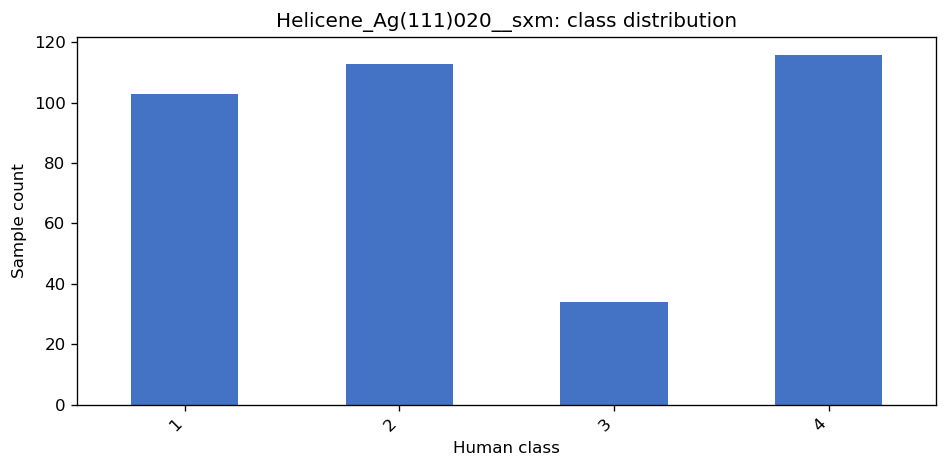

In [4]:
# Show the number of classes, total samples, and samples per class.
class_counts = labeled['human_class'].value_counts().sort_index()
print('Number of classes:', len(class_counts))
print('Number of samples:', len(labeled))

if class_counts.empty:
    print('No class statistics yet. Fill in human_class first.')
else:
    display(class_counts.rename('Sample count').to_frame())
    ax = class_counts.plot(kind='bar', figsize=(8, 4), color='#4472C4')
    ax.set_xlabel('Human class')
    ax.set_ylabel('Sample count')
    ax.set_title('{}: class distribution'.format(ACTIVE_IMAGE))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

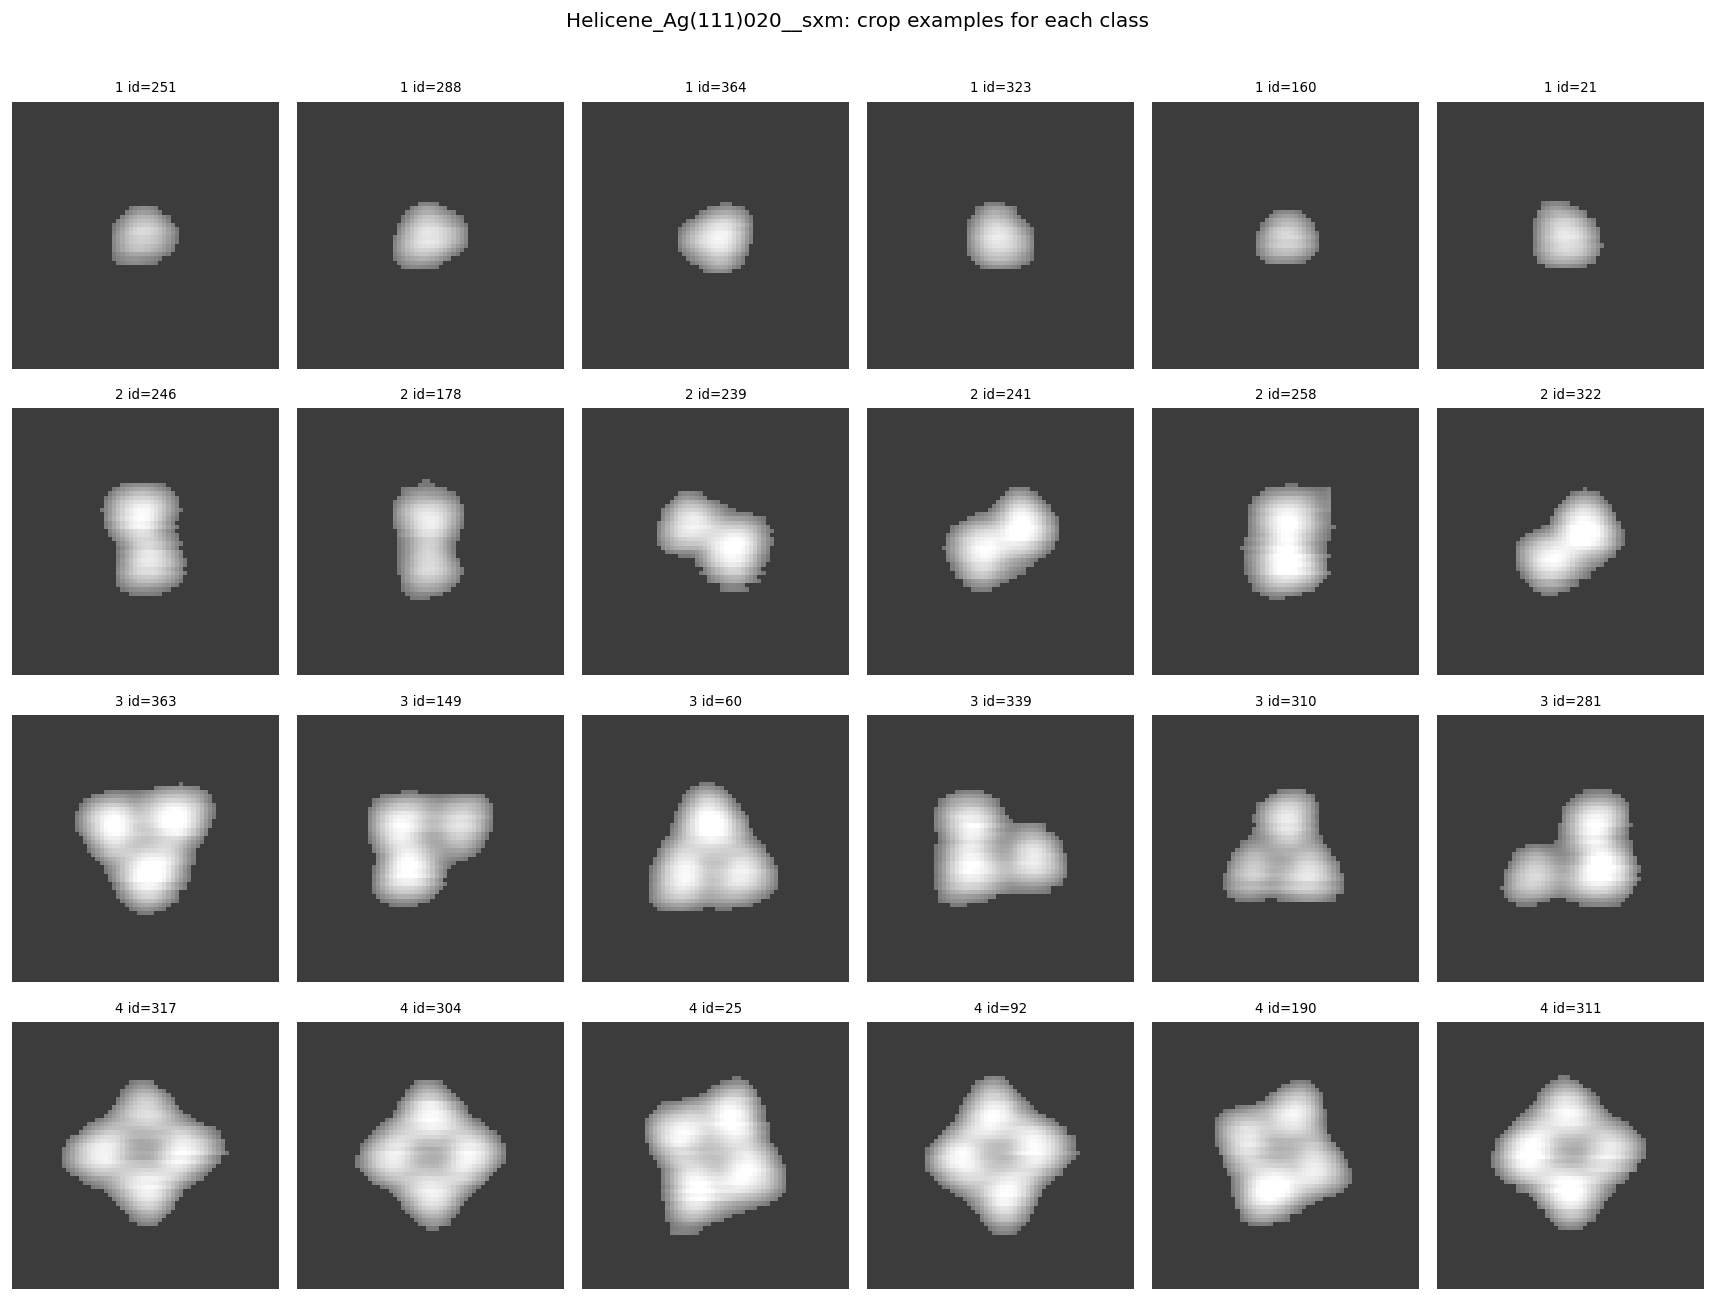

Tip: check manual_labels.csv if a class has large shape variation or classes look similar.


In [5]:
def show_examples_per_class(dataframe, examples_per_class=6, seed=42):
    if dataframe.empty:
        print('There are no manually labelled samples to display.')
        return

    class_names = sorted(dataframe['human_class'].unique())
    figure, axes = plt.subplots(
        len(class_names), examples_per_class,
        figsize=(2.4 * examples_per_class, 2.7 * len(class_names)),
        squeeze=False,
    )
    rng = np.random.default_rng(seed)

    for row_index, class_name in enumerate(class_names):
        class_rows = dataframe[dataframe['human_class'] == class_name]
        sample_size = min(examples_per_class, len(class_rows))
        chosen_indices = rng.choice(
            class_rows.index.to_numpy(), size=sample_size, replace=False
        )
        chosen_rows = class_rows.loc[chosen_indices]

        for column_index, (_, record) in enumerate(chosen_rows.iterrows()):
            axis = axes[row_index, column_index]
            with Image.open(record['_crop_path']) as image:
                axis.imshow(image.convert('L'), vmin=0, vmax=255)
            candidate_id = record.get('candidate_id', '')
            axis.set_title('{} id={}'.format(class_name, candidate_id), fontsize=8)
            axis.axis('off')

        for column_index in range(sample_size, examples_per_class):
            axes[row_index, column_index].axis('off')

    figure.suptitle('{}: crop examples for each class'.format(ACTIVE_IMAGE), y=1.01)
    plt.tight_layout()
    plt.show()


show_examples_per_class(labeled, examples_per_class=6)
print('Tip: check manual_labels.csv if a class has large shape variation or classes look similar.')

In [6]:
# Image input and augmentation settings.
# Training uses random rotations only, preserving molecular chirality.
IMAGE_SIZE = 64
ROTATION_DEGREES = 180
BATCH_SIZE = 16
VALIDATION_FRACTION = 0.20
# EPOCHS = 30
EPOCHS = 100
LEARNING_RATE = 1e-3
BALANCED_TRAINING = True

def make_transform(train=False, fixed_angle=None):
    operations = [transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))]
    if fixed_angle is not None:
        operations.append(
            transforms.Lambda(
                lambda image: transforms.functional.rotate(image, fixed_angle, fill=128)
            )
        )
    elif train:
        operations.extend([
            transforms.RandomRotation(ROTATION_DEGREES, fill=128),
        ])
    operations.extend([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
    return transforms.Compose(operations)

train_transform = make_transform(train=True)
validation_transform = make_transform(train=False)
print('Training augmentation: random rotation only, ±180 degrees')
print('Input size:', (IMAGE_SIZE, IMAGE_SIZE))

Training augmentation: random rotation only, ±180 degrees
Input size: (64, 64)


In [7]:
class MoleculeCropDataset(Dataset):
    # The dataset uses only _crop_path and _label_id; no original image or label is read.
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        record = self.dataframe.iloc[index]
        with Image.open(record['_crop_path']) as image:
            image = image.convert('L')
            image = self.transform(image)
        return image, int(record['_label_id'])


class BalancedClassSampler(Sampler):
    # Draw exactly the same number of samples from every class in each epoch.
    # Sampling with replacement lets smaller classes receive more random rotations.
    def __init__(self, labels, seed=SEED):
        self.labels = np.asarray(labels, dtype=int)
        self.class_ids = np.sort(np.unique(self.labels))
        self.indices_by_class = {
            class_id: np.flatnonzero(self.labels == class_id)
            for class_id in self.class_ids
        }
        self.samples_per_class = max(
            len(indices) for indices in self.indices_by_class.values()
        )
        self.seed = seed
        self.epoch = 0

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        sampled_indices = []
        for class_id in self.class_ids:
            sampled_indices.extend(
                rng.choice(
                    self.indices_by_class[class_id],
                    size=self.samples_per_class,
                    replace=True,
                ).tolist()
            )
        rng.shuffle(sampled_indices)
        self.epoch += 1
        return iter(sampled_indices)

    def __len__(self):
        return len(self.class_ids) * self.samples_per_class


class SimpleMoleculeCNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()
        # self.features = nn.Sequential(
        #     nn.Conv2d(1, 32, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(32),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(2),

        #     nn.Conv2d(32, 64, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(64),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(2),

        #     nn.Conv2d(64, 128, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(inplace=True),
        #     nn.AdaptiveAvgPool2d((1, 1)),
        # )

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            # nn.Linear(128, number_of_classes),
            nn.Linear(256, number_of_classes),
        )

    def forward(self, inputs):
        return self.classifier(self.features(inputs))


def stratified_split(dataframe, validation_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_indices, validation_indices = [], []
    for _, group in dataframe.groupby('human_class', sort=True):
        indices = group.index.to_numpy().copy()
        rng.shuffle(indices)
        validation_count = max(1, int(round(len(indices) * validation_fraction)))
        validation_count = min(validation_count, len(indices) - 1)
        validation_indices.extend(indices[:validation_count])
        train_indices.extend(indices[validation_count:])
    return (
        dataframe.loc[sorted(train_indices)].reset_index(drop=True),
        dataframe.loc[sorted(validation_indices)].reset_index(drop=True),
    )


def run_epoch(model, loader, loss_function, optimizer=None, device='cpu'):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        if is_training:
            optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_function(logits, targets)
        if is_training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(targets)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += len(targets)
    return total_loss / total, correct / total

In [8]:
# Training example. Training is skipped if labels are missing or too small for a split.
trained = False
history = []
model = None
class_names = []

if labeled.empty:
    print('Training skipped: manual_labels.csv has no non-empty human_class values.')
elif labeled['human_class'].nunique() < 2:
    print('Training skipped: at least two human_class values are required.')
elif labeled['human_class'].value_counts().min() < 2:
    print('Training skipped: each human_class needs at least two crops.')
else:
    class_names = sorted(labeled['human_class'].unique())
    class_to_id = {name: index for index, name in enumerate(class_names)}
    train_records, validation_records = stratified_split(
        labeled, validation_fraction=VALIDATION_FRACTION, seed=SEED
    )
    train_records['_label_id'] = train_records['human_class'].map(class_to_id).astype(int)
    validation_records['_label_id'] = validation_records['human_class'].map(class_to_id).astype(int)

    train_dataset = MoleculeCropDataset(train_records, train_transform)
    validation_dataset = MoleculeCropDataset(validation_records, validation_transform)
    if BALANCED_TRAINING:
        train_sampler = BalancedClassSampler(
            train_records['_label_id'].to_numpy(), seed=SEED
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size=min(BATCH_SIZE, len(train_sampler)),
            sampler=train_sampler,
            num_workers=0,
        )
        original_counts = train_records['_label_id'].value_counts().sort_index()
        print('Original training counts:', original_counts.to_dict())
        print(
            'Balanced training counts per epoch:',
            {int(class_id): train_sampler.samples_per_class for class_id in train_sampler.class_ids},
        )
    else:
        train_sampler = None
        train_loader = DataLoader(
            train_dataset,
            batch_size=min(BATCH_SIZE, len(train_dataset)),
            shuffle=True,
            num_workers=0,
        )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=min(BATCH_SIZE, len(validation_dataset)),
        shuffle=False,
        num_workers=0,
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleMoleculeCNN(len(class_names)).to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_validation_accuracy, best_state = -1.0, None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_accuracy = run_epoch(
            model, train_loader, loss_function, optimizer=optimizer, device=device
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function, optimizer=None, device=device
        )
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'validation_loss': validation_loss,
            'validation_accuracy': validation_accuracy,
        })
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
            print(
                'epoch {:02d}/{:02d} | train acc {:.3f} | validation acc {:.3f}'.format(
                    epoch, EPOCHS, train_accuracy, validation_accuracy
                )
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    trained = True
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'image_name': ACTIVE_IMAGE,
        'image_size': IMAGE_SIZE,
    }, OUTPUT_DIRECTORY / 'model.pt')
    pd.DataFrame(history).to_csv(OUTPUT_DIRECTORY / 'training_history.csv', index=False)
    with open(OUTPUT_DIRECTORY / 'class_names.json', 'w', encoding='utf-8') as file:
        json.dump(class_names, file, ensure_ascii=False, indent=2)
    print('Model and training records saved to:', OUTPUT_DIRECTORY)

Original training counts: {0: 82, 1: 90, 2: 27, 3: 93}
Balanced training counts per epoch: {0: 93, 1: 93, 2: 93, 3: 93}
epoch 01/100 | train acc 0.718 | validation acc 0.284
epoch 05/100 | train acc 0.952 | validation acc 0.919
epoch 10/100 | train acc 0.965 | validation acc 0.973
epoch 15/100 | train acc 0.989 | validation acc 0.959
epoch 20/100 | train acc 0.976 | validation acc 0.851
epoch 25/100 | train acc 0.973 | validation acc 1.000
epoch 30/100 | train acc 0.976 | validation acc 0.797
epoch 35/100 | train acc 0.987 | validation acc 1.000
epoch 40/100 | train acc 0.984 | validation acc 0.973
epoch 45/100 | train acc 0.987 | validation acc 0.973
epoch 50/100 | train acc 0.978 | validation acc 1.000
epoch 55/100 | train acc 0.970 | validation acc 0.689
epoch 60/100 | train acc 0.987 | validation acc 0.986
epoch 65/100 | train acc 0.981 | validation acc 0.973
epoch 70/100 | train acc 0.989 | validation acc 1.000
epoch 75/100 | train acc 0.989 | validation acc 1.000
epoch 80/100 | t

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
95,96,0.014378,0.997312,0.025719,0.986486
96,97,0.037992,0.986559,0.009651,1.000000
97,98,0.022569,0.991935,0.004132,1.000000
98,99,0.072148,0.978495,0.005247,1.000000
99,100,0.016809,0.997312,0.004574,1.000000


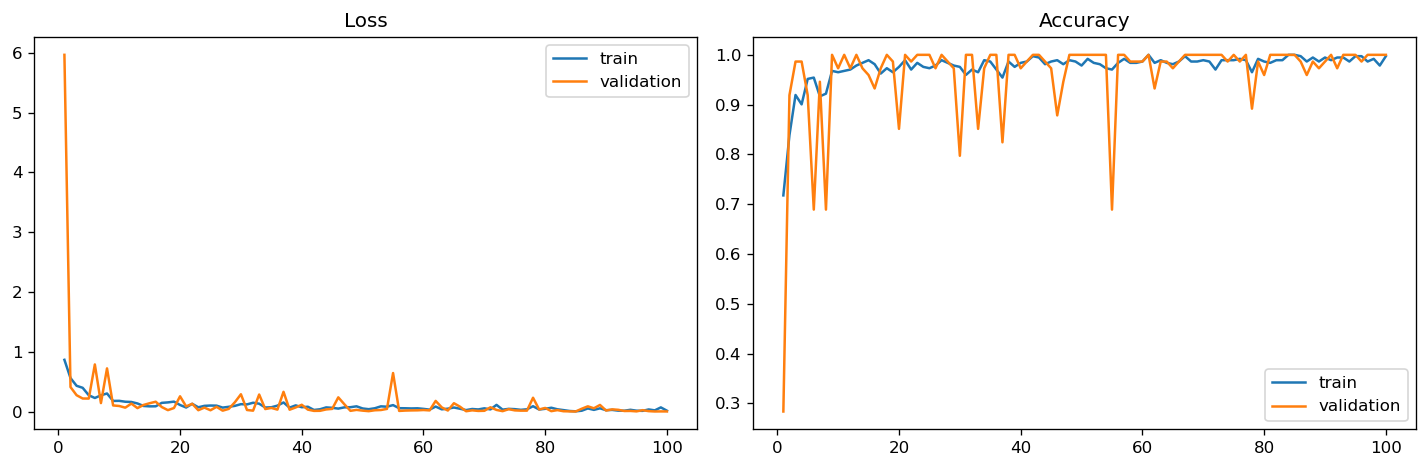

Rows are true classes; columns are predicted classes:


,1,2,3,4
1,21,0,0,0
2,0,23,0,0
3,0,0,7,0
4,0,0,0,23


,rotation_degree,accuracy
0,0,1.000000
1,45,0.972973
2,90,1.000000
3,135,0.945946
4,180,1.000000
5,225,0.986486
6,270,1.000000
7,315,0.959459


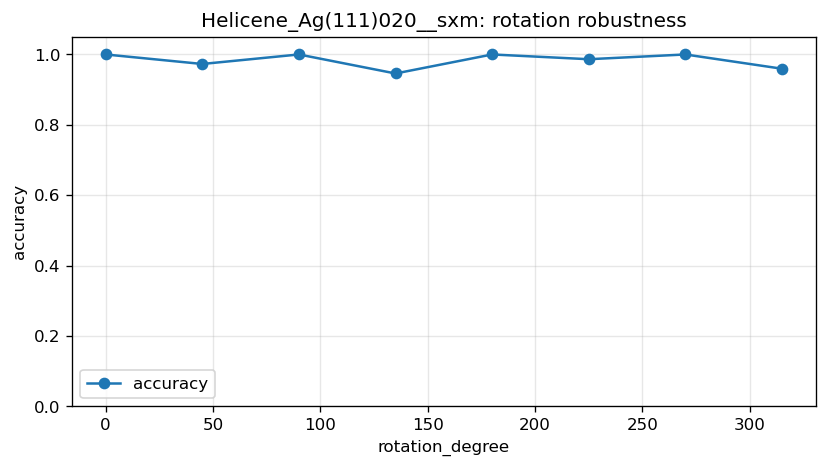

Rotation test results saved to: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm/rotation_robustness.csv


In [9]:
# View training curves, the confusion matrix, and rotation robustness.
if not trained:
    print('No training results to display.')
else:
    history_frame = pd.DataFrame(history)
    display(history_frame.tail())
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_frame['epoch'], history_frame['train_loss'], label='train')
    axes[0].plot(history_frame['epoch'], history_frame['validation_loss'], label='validation')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(history_frame['epoch'], history_frame['train_accuracy'], label='train')
    axes[1].plot(history_frame['epoch'], history_frame['validation_accuracy'], label='validation')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    true_ids, predicted_ids = [], []
    with torch.no_grad():
        for images, targets in validation_loader:
            logits = model(images.to(device))
            true_ids.extend(targets.numpy().tolist())
            predicted_ids.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    confusion = np.zeros((len(class_names), len(class_names)), dtype=int)
    for true_id, predicted_id in zip(true_ids, predicted_ids):
        confusion[true_id, predicted_id] += 1
    confusion_frame = pd.DataFrame(confusion, index=class_names, columns=class_names)
    print('Rows are true classes; columns are predicted classes:')
    display(confusion_frame)
    confusion_frame.to_csv(OUTPUT_DIRECTORY / 'confusion_matrix.csv', encoding='utf-8-sig')

    rotation_results = []
    for angle in range(0, 360, 45):
        rotated_dataset = MoleculeCropDataset(
            validation_records, make_transform(fixed_angle=angle)
        )
        rotated_loader = DataLoader(
            rotated_dataset,
            batch_size=min(BATCH_SIZE, len(rotated_dataset)),
            shuffle=False,
            num_workers=0,
        )
        _, accuracy = run_epoch(
            model, rotated_loader, loss_function, optimizer=None, device=device
        )
        rotation_results.append({'rotation_degree': angle, 'accuracy': accuracy})
    rotation_frame = pd.DataFrame(rotation_results)
    display(rotation_frame)
    rotation_frame.plot(
        x='rotation_degree',
        y='accuracy',
        marker='o',
        ylim=(0, 1.05),
        figsize=(8, 4),
        title='{}: rotation robustness'.format(ACTIVE_IMAGE),
    )
    plt.ylabel('accuracy')
    plt.grid(alpha=0.3)
    plt.show()
    rotation_frame.to_csv(OUTPUT_DIRECTORY / 'rotation_robustness.csv', index=False)
    print('Rotation test results saved to:', OUTPUT_DIRECTORY / 'rotation_robustness.csv')

## Overall Confusion Matrix and Prediction Examples

The following cells use the validation predictions for the current ACTIVE_IMAGE to create an overall confusion matrix and inspect correctly and incorrectly classified molecule crops.

In [10]:
# Save per-sample validation predictions for the confusion matrix and image displays.
if not trained:
    print('No training results; per-sample predictions cannot be generated.')
else:
    prediction_dataset = MoleculeCropDataset(validation_records, validation_transform)
    prediction_loader = DataLoader(
        prediction_dataset,
        batch_size=min(BATCH_SIZE, len(prediction_dataset)),
        shuffle=False,
        num_workers=0,
    )
    predicted_ids, confidences = [], []
    model.eval()
    with torch.no_grad():
        for images, _ in prediction_loader:
            probabilities = torch.softmax(model(images.to(device)), dim=1)
            predicted_ids.extend(probabilities.argmax(dim=1).cpu().numpy().tolist())
            confidences.extend(probabilities.max(dim=1).values.cpu().numpy().tolist())

    prediction_frame = validation_records.reset_index(drop=True).copy()
    prediction_frame['true_id'] = prediction_frame['_label_id'].astype(int)
    prediction_frame['predicted_id'] = predicted_ids
    prediction_frame['true_class'] = prediction_frame['true_id'].map(
        lambda value: class_names[int(value)]
    )
    prediction_frame['predicted_class'] = prediction_frame['predicted_id'].map(
        lambda value: class_names[int(value)]
    )
    prediction_frame['confidence'] = confidences
    prediction_frame['correct'] = (
        prediction_frame['true_id'] == prediction_frame['predicted_id']
    )

    display_columns = [
        column for column in [
            'candidate_id', 'true_class', 'predicted_class',
            'confidence', 'correct', 'crop_path'
        ] if column in prediction_frame.columns
    ]
    display(prediction_frame[display_columns].head(20))
    prediction_frame.drop(columns=['_crop_path'], errors='ignore').to_csv(
        OUTPUT_DIRECTORY / 'validation_predictions.csv',
        index=False,
        encoding='utf-8-sig',
    )
    print('Per-sample predictions saved to:', OUTPUT_DIRECTORY / 'validation_predictions.csv')

,candidate_id,true_class,predicted_class,confidence,correct,crop_path
0,2,1,1,0.979771,True,crops/candidate_0002.png
1,4,1,1,0.976098,True,crops/candidate_0004.png
2,7,4,4,0.924547,True,crops/candidate_0007.png
3,12,1,1,0.953140,True,crops/candidate_0012.png
4,27,4,4,0.860636,True,crops/candidate_0027.png
5,28,2,2,0.745797,True,crops/candidate_0028.png
6,29,2,2,0.841367,True,crops/candidate_0029.png
7,43,4,4,0.846777,True,crops/candidate_0043.png
8,53,3,3,0.908846,True,crops/candidate_0053.png
9,68,2,2,0.890927,True,crops/candidate_0068.png


Per-sample predictions saved to: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm/validation_predictions.csv


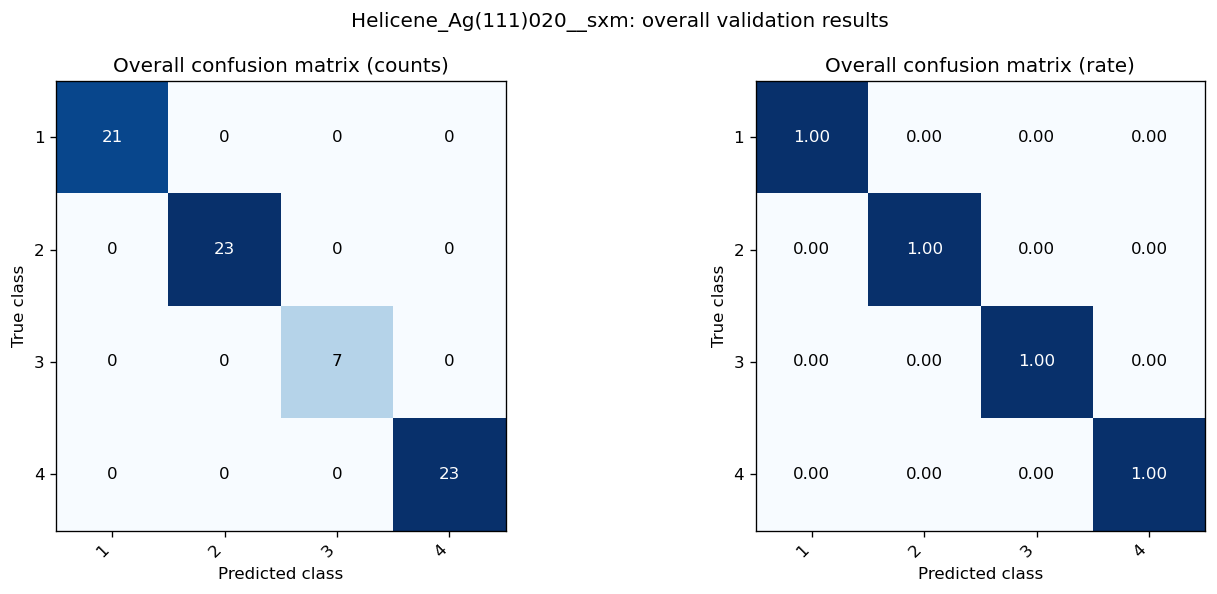

predicted_class,1,2,3,4
true_class,,,,
1,21,0,0,0
2,0,23,0,0
3,0,0,7,0
4,0,0,0,23


Confusion-matrix data and image saved to: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm


In [11]:
# Overall confusion matrix: counts on the left and true-class-normalized rates on the right.
if not trained or 'prediction_frame' not in globals():
    print('No per-sample predictions; the confusion matrix cannot be plotted.')
else:
    overall_confusion_frame = pd.crosstab(
        prediction_frame['true_class'],
        prediction_frame['predicted_class'],
    ).reindex(index=class_names, columns=class_names, fill_value=0)
    raw_matrix = overall_confusion_frame.to_numpy(dtype=int)
    row_totals = raw_matrix.sum(axis=1, keepdims=True)
    normalized_matrix = np.divide(
        raw_matrix.astype(float),
        row_totals,
        out=np.zeros_like(raw_matrix, dtype=float),
        where=row_totals != 0,
    )
    normalized_frame = pd.DataFrame(
        normalized_matrix, index=class_names, columns=class_names
    )

    def draw_matrix(axis, matrix, title, value_format):
        image = axis.imshow(matrix, cmap='Blues', vmin=0, vmax=max(1, matrix.max()))
        axis.set_title(title)
        axis.set_xlabel('Predicted class')
        axis.set_ylabel('True class')
        axis.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right')
        axis.set_yticks(range(len(class_names)), class_names)
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                axis.text(
                    column, row, value_format.format(matrix[row, column]),
                    ha='center', va='center',
                    color='white' if matrix[row, column] > matrix.max() * 0.55 else 'black',
                )
        return image

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    draw_matrix(axes[0], raw_matrix, 'Overall confusion matrix (counts)', '{:.0f}')
    draw_matrix(axes[1], normalized_matrix, 'Overall confusion matrix (rate)', '{:.2f}')
    figure.suptitle('{}: overall validation results'.format(ACTIVE_IMAGE))
    figure.tight_layout()
    plt.show()
    display(overall_confusion_frame)
    overall_confusion_frame.to_csv(
        OUTPUT_DIRECTORY / 'overall_confusion_matrix.csv', encoding='utf-8-sig'
    )
    normalized_frame.to_csv(
        OUTPUT_DIRECTORY / 'overall_confusion_matrix_normalized.csv',
        encoding='utf-8-sig',
    )
    figure.savefig(
        OUTPUT_DIRECTORY / 'overall_confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    print('Confusion-matrix data and image saved to:', OUTPUT_DIRECTORY)

In [12]:
def show_prediction_examples(dataframe, title, number=10, columns=5):
    if dataframe.empty:
        print('{}: no samples.'.format(title))
        return

    selected = dataframe.sort_values('confidence', ascending=False).head(number)
    rows = int(np.ceil(len(selected) / columns))
    figure, axes = plt.subplots(
        rows, columns, figsize=(2.8 * columns, 3.2 * rows), squeeze=False
    )
    for plot_index, (_, record) in enumerate(selected.iterrows()):
        axis = axes[plot_index // columns, plot_index % columns]
        with Image.open(record['_crop_path']) as image:
            axis.imshow(image.convert('L'), vmin=0, vmax=255)
        axis.set_title(
            'id={} true={} pred={} conf={:.2f}'.format(
                record.get('candidate_id', ''),
                record['true_class'],
                record['predicted_class'],
                record['confidence'],
            ),
            fontsize=8,
        )
        axis.axis('off')
    for plot_index in range(len(selected), rows * columns):
        axes[plot_index // columns, plot_index % columns].axis('off')
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

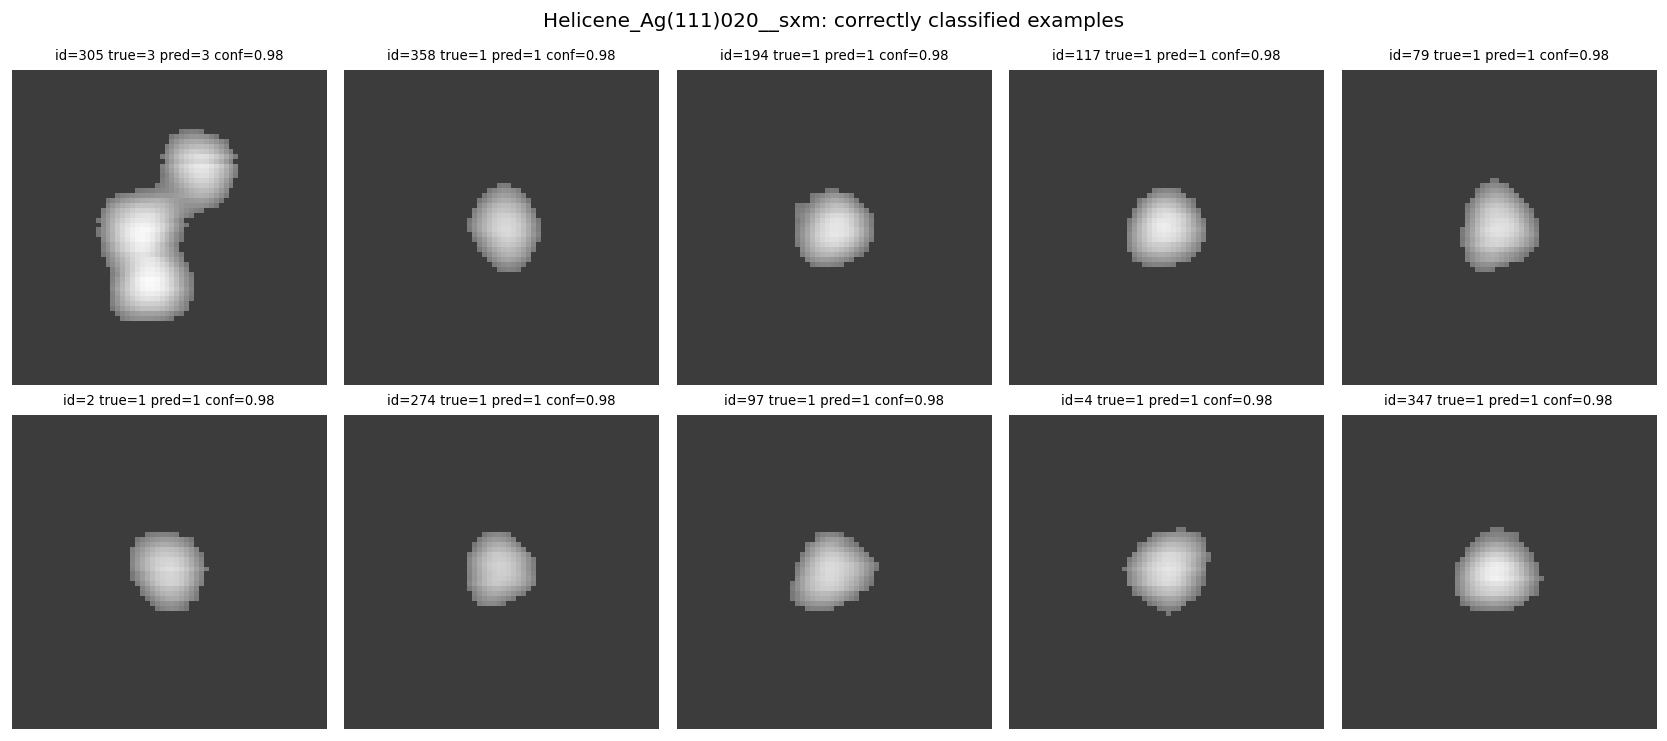

In [13]:
# Correctly classified examples, shown from highest to lowest confidence.
if not trained or 'prediction_frame' not in globals():
    print('No per-sample predictions; correct examples cannot be displayed.')
else:
    show_prediction_examples(
        prediction_frame[prediction_frame['correct']],
        '{}: correctly classified examples'.format(ACTIVE_IMAGE),
        number=10,
    )

In [14]:
# Incorrectly classified examples. High-confidence mistakes are shown first.
if not trained or 'prediction_frame' not in globals():
    print('No per-sample predictions; incorrect examples cannot be displayed.')
else:
    show_prediction_examples(
        prediction_frame[~prediction_frame['correct']],
        '{}: incorrectly classified examples'.format(ACTIVE_IMAGE),
        number=10,
    )

Helicene_Ag(111)020__sxm: incorrectly classified examples: no samples.


## How to Switch Between Datasets

Return to the path-configuration cell, change ACTIVE_IMAGE to Helicene_Ag(111)020__sxm, and rerun from that cell onward.

The manual-label files are located in the following dataset folders:

- Ag111_APT_CO_044__p/manual_labels.csv
- Helicene_Ag(111)020__sxm/manual_labels.csv

Before training, fill in human_class in the selected CSV and make sure the files referenced by crop_path exist. Rows with an empty human_class are excluded. This notebook does not read original .p labels, so the same workflow can be used for images without reference annotations.

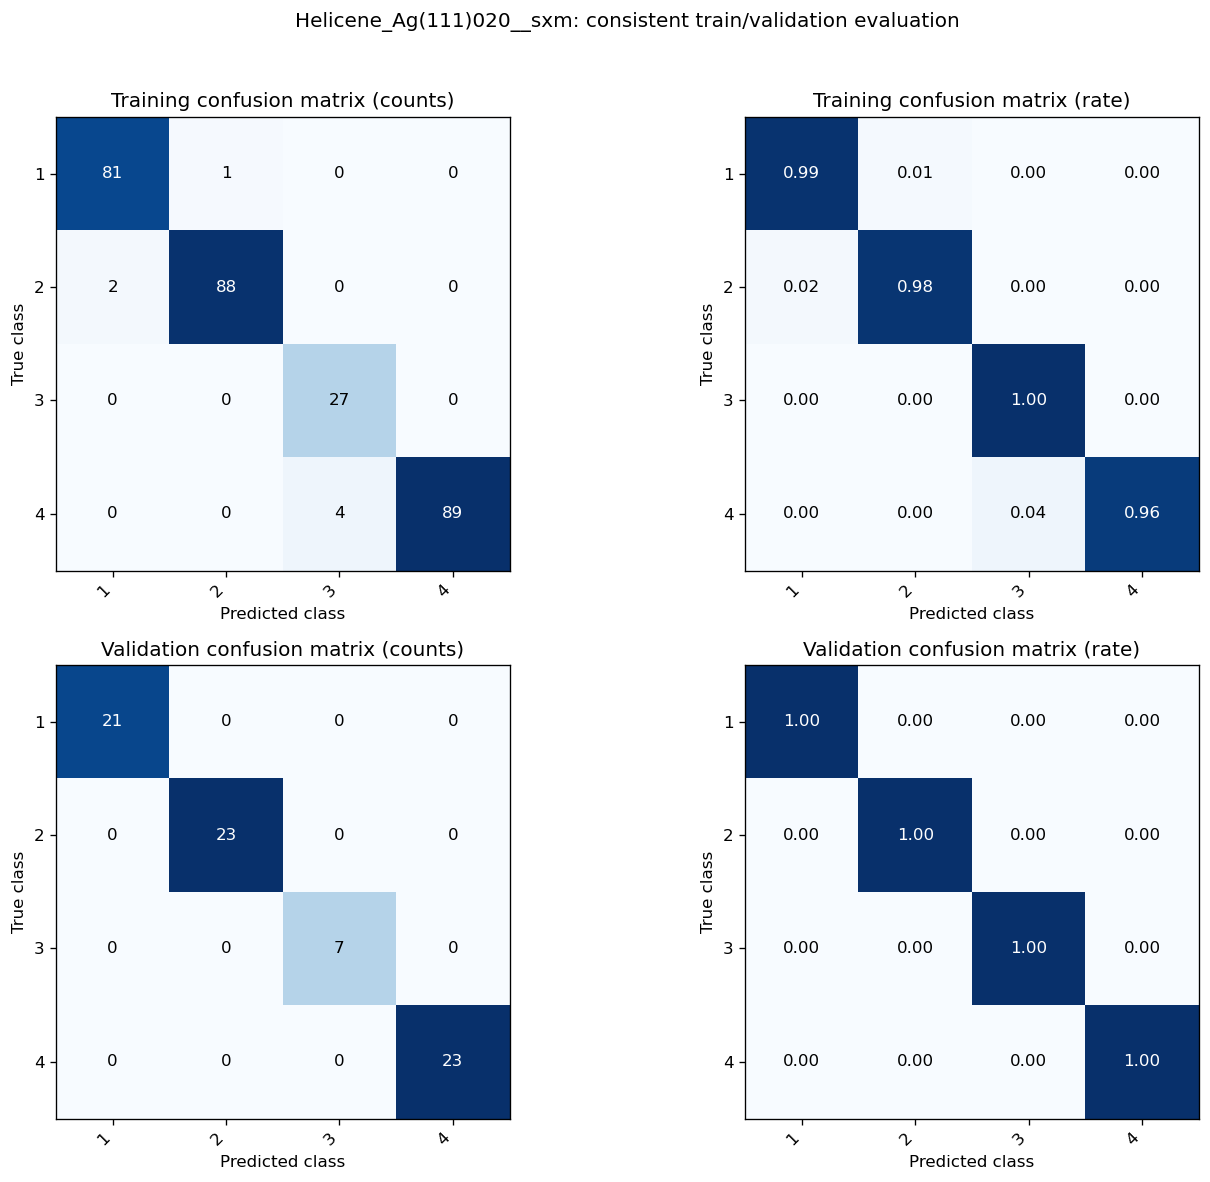

,split,correct,total,accuracy
0,Training,285,292,0.976027
1,Validation,74,74,1.000000


Consistent train/validation results saved to: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm


In [15]:
# Evaluate the same final model on the training and validation sets.
# Both splits use model.eval() and the same deterministic validation_transform.
if not trained or 'train_records' not in globals() or 'validation_records' not in globals():
    print('No trained model or split records are available. Run the training cell first.')
else:
    evaluation_specs = [
        ('Training', train_records, 'training'),
        ('Validation', validation_records, 'validation'),
    ]
    split_results = {}
    model.eval()

    with torch.no_grad():
        for split_name, records, file_stem in evaluation_specs:
            evaluation_dataset = MoleculeCropDataset(records, validation_transform)
            evaluation_loader = DataLoader(
                evaluation_dataset,
                batch_size=min(BATCH_SIZE, len(evaluation_dataset)),
                shuffle=False,
                num_workers=0,
            )
            true_ids, predicted_ids = [], []
            for images, targets in evaluation_loader:
                logits = model(images.to(device))
                true_ids.extend(targets.numpy().tolist())
                predicted_ids.extend(logits.argmax(dim=1).cpu().numpy().tolist())

            confusion = np.zeros((len(class_names), len(class_names)), dtype=int)
            for true_id, predicted_id in zip(true_ids, predicted_ids):
                confusion[true_id, predicted_id] += 1
            row_totals = confusion.sum(axis=1, keepdims=True)
            normalized = np.divide(
                confusion.astype(float),
                row_totals,
                out=np.zeros_like(confusion, dtype=float),
                where=row_totals != 0,
            )
            accuracy = np.trace(confusion) / confusion.sum()
            split_results[split_name] = {
                'confusion': confusion,
                'normalized': normalized,
                'accuracy': accuracy,
                'count': int(confusion.sum()),
            }

            pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(
                OUTPUT_DIRECTORY / '{}_confusion_matrix_consistent.csv'.format(file_stem),
                encoding='utf-8-sig',
            )
            pd.DataFrame(normalized, index=class_names, columns=class_names).to_csv(
                OUTPUT_DIRECTORY / '{}_confusion_matrix_consistent_normalized.csv'.format(file_stem),
                encoding='utf-8-sig',
            )

    figure, axes = plt.subplots(2, 2, figsize=(12, 10))
    for row, split_name in enumerate(['Training', 'Validation']):
        result = split_results[split_name]
        for column, (title, matrix, value_format, vmax) in enumerate([
            ('{} confusion matrix (counts)'.format(split_name), result['confusion'], '{:.0f}', max(1, result['confusion'].max())),
            ('{} confusion matrix (rate)'.format(split_name), result['normalized'], '{:.2f}', 1),
        ]):
            axis = axes[row, column]
            axis.imshow(matrix, cmap='Blues', vmin=0, vmax=vmax)
            axis.set_title(title)
            axis.set_xlabel('Predicted class')
            axis.set_ylabel('True class')
            axis.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right')
            axis.set_yticks(range(len(class_names)), class_names)
            for matrix_row in range(matrix.shape[0]):
                for matrix_column in range(matrix.shape[1]):
                    axis.text(
                        matrix_column, matrix_row, value_format.format(matrix[matrix_row, matrix_column]),
                        ha='center', va='center',
                        color='white' if matrix[matrix_row, matrix_column] > vmax * 0.55 else 'black',
                    )

    figure.suptitle('{}: consistent train/validation evaluation'.format(ACTIVE_IMAGE))
    figure.tight_layout(rect=(0, 0, 1, 0.96))
    figure.savefig(
        OUTPUT_DIRECTORY / 'training_validation_confusion_matrices.png',
        dpi=180, bbox_inches='tight',
    )
    plt.show()

    performance_frame = pd.DataFrame([
        {
            'split': split_name,
            'correct': int(np.trace(split_results[split_name]['confusion'])),
            'total': split_results[split_name]['count'],
            'accuracy': split_results[split_name]['accuracy'],
        }
        for split_name in ['Training', 'Validation']
    ])
    display(performance_frame)
    performance_frame.to_csv(
        OUTPUT_DIRECTORY / 'training_validation_accuracy_consistent.csv',
        index=False, encoding='utf-8-sig',
    )
    print('Consistent train/validation results saved to:', OUTPUT_DIRECTORY)

,candidate_id,true_class,predicted_class,confidence,crop_path
132,162,2,1,0.960277,crops/candidate_0162.png
140,171,2,1,0.929952,crops/candidate_0171.png
62,74,1,2,0.851708,crops/candidate_0074.png
6,10,4,3,0.826987,crops/candidate_0010.png
65,77,4,3,0.791871,crops/candidate_0077.png
155,188,4,3,0.662792,crops/candidate_0188.png
168,206,4,3,0.656069,crops/candidate_0206.png


Incorrect training samples: 7


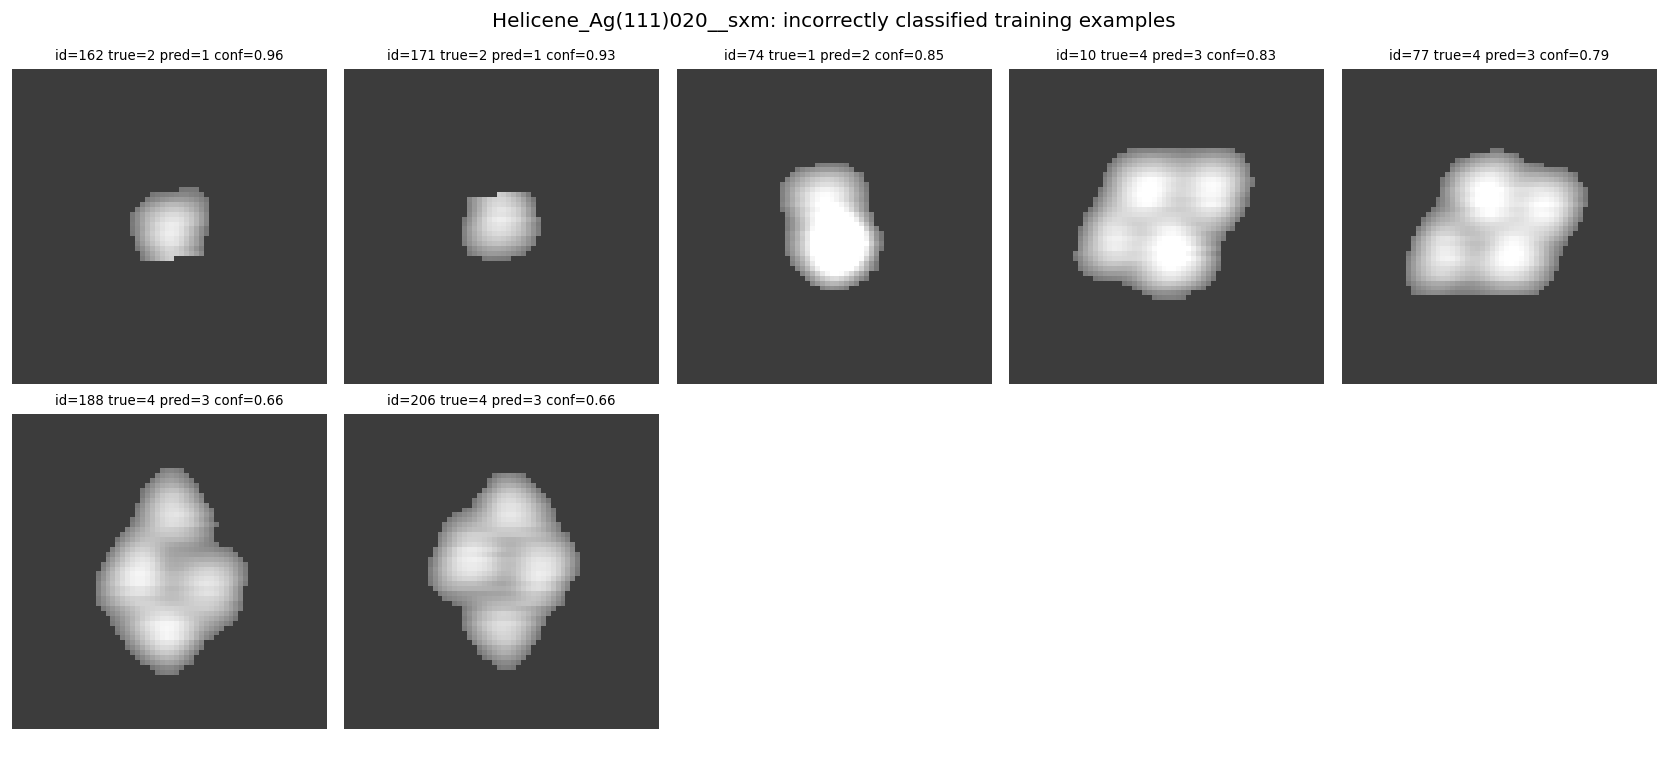

Training prediction files saved to: /Users/jiajie/Desktop/ADS2002GroupCM1/Data/cnn_results/Helicene_Ag(111)020__sxm


In [16]:
# Show incorrectly classified training crops using the same final model and evaluation transform.
if not trained or 'train_records' not in globals():
    print('No trained model or training records are available. Run the training cell first.')
else:
    training_prediction_dataset = MoleculeCropDataset(train_records, validation_transform)
    training_prediction_loader = DataLoader(
        training_prediction_dataset,
        batch_size=min(BATCH_SIZE, len(training_prediction_dataset)),
        shuffle=False,
        num_workers=0,
    )

    training_true_ids, training_predicted_ids, training_confidences = [], [], []
    model.eval()
    with torch.no_grad():
        for images, targets in training_prediction_loader:
            probabilities = torch.softmax(model(images.to(device)), dim=1)
            training_true_ids.extend(targets.numpy().tolist())
            training_predicted_ids.extend(
                probabilities.argmax(dim=1).cpu().numpy().tolist()
            )
            training_confidences.extend(
                probabilities.max(dim=1).values.cpu().numpy().tolist()
            )

    training_prediction_frame = train_records.reset_index(drop=True).copy()
    training_prediction_frame['true_id'] = training_true_ids
    training_prediction_frame['predicted_id'] = training_predicted_ids
    training_prediction_frame['true_class'] = training_prediction_frame['true_id'].map(
        lambda value: class_names[int(value)]
    )
    training_prediction_frame['predicted_class'] = training_prediction_frame['predicted_id'].map(
        lambda value: class_names[int(value)]
    )
    training_prediction_frame['confidence'] = training_confidences
    training_prediction_frame['correct'] = (
        training_prediction_frame['true_id'] == training_prediction_frame['predicted_id']
    )

    training_prediction_frame.drop(columns=['_crop_path'], errors='ignore').to_csv(
        OUTPUT_DIRECTORY / 'training_predictions_consistent.csv',
        index=False, encoding='utf-8-sig',
    )
    incorrect_training_frame = training_prediction_frame[
        ~training_prediction_frame['correct']
    ].sort_values('confidence', ascending=False)
    incorrect_training_frame.drop(columns=['_crop_path'], errors='ignore').to_csv(
        OUTPUT_DIRECTORY / 'training_incorrect_predictions.csv',
        index=False, encoding='utf-8-sig',
    )

    display_columns = [
        column for column in [
            'candidate_id', 'true_class', 'predicted_class',
            'confidence', 'crop_path'
        ] if column in incorrect_training_frame.columns
    ]
    display(incorrect_training_frame[display_columns])
    print('Incorrect training samples:', len(incorrect_training_frame))
    if incorrect_training_frame.empty:
        print('No incorrectly classified training samples.')
    else:
        show_prediction_examples(
            incorrect_training_frame,
            '{}: incorrectly classified training examples'.format(ACTIVE_IMAGE),
            number=min(20, len(incorrect_training_frame)),
        )
    print('Training prediction files saved to:', OUTPUT_DIRECTORY)